In [39]:
# ==========================================
# IMPORT LIBRARIES
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import re
import nltk

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

import warnings
warnings.filterwarnings('ignore')

In [40]:
# ==========================================
# DOWNLOAD NLTK DATA
# ==========================================

nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [41]:
# ==========================================
# LOAD DATASET
# ==========================================

df = pd.read_csv('/content/customer_support_text_classification.csv')

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [42]:
# ==========================================
# DATASET OVERVIEW
# ==========================================

df.head()

,ticket_id,channel,customer_message,sentiment_label,word_count,urgent_flag
0,TKT00001,chat,I need information about the payment process. ...,neutral,18,1
1,TKT00002,phone,I need information about the payment process.,neutral,7,0
2,TKT00003,email,The refund process was fast and convenient. I ...,positive,12,0
3,TKT00004,social,My refund is still pending and this experience...,negative,15,1
4,TKT00005,chat,Please tell me how to update my account details.,neutral,9,0


In [43]:
# ==========================================
# DATASET SHAPE
# ==========================================

print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Number of Rows: 1500
Number of Columns: 6


In [44]:
# ==========================================
# COLUMN NAMES
# ==========================================

print(df.columns)

Index(['ticket_id', 'channel', 'customer_message', 'sentiment_label',
       'word_count', 'urgent_flag'],
      dtype='object')


In [45]:
# ==========================================
# CHECK MISSING VALUES
# ==========================================

df.isnull().sum()

,0
ticket_id,0
channel,0
customer_message,0
sentiment_label,0
word_count,0
urgent_flag,0


In [46]:
# ==========================================
# TARGET LABELS
# ==========================================

print("Target Classes:")
print(df['sentiment_label'].unique())

Target Classes:
['neutral' 'positive' 'negative']


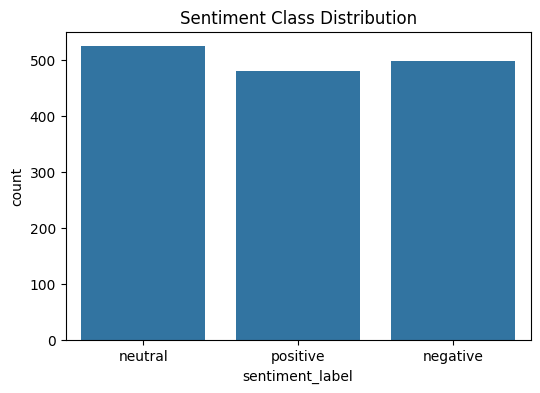

In [47]:
# ==========================================
# CLASS DISTRIBUTION
# ==========================================

plt.figure(figsize=(6,4))

sns.countplot(x='sentiment_label', data=df)

plt.title("Sentiment Class Distribution")

plt.show()

In [48]:
# ==========================================
# AVERAGE TEXT LENGTH
# ==========================================

df['message_length'] = df['customer_message'].apply(len)

print("Average Text Length:", df['message_length'].mean())

Average Text Length: 72.75666666666666


In [49]:
# ==========================================
# SAMPLE TEXT RECORDS
# ==========================================

for i in range(5):
    print(f"\nSample {i+1}")
    print(df['customer_message'][i])


Sample 1
I need information about the payment process. My ticket number is 78732. Please respond as soon as possible.

Sample 2
I need information about the payment process.

Sample 3
The refund process was fast and convenient. I appreciate the quick response.

Sample 4
My refund is still pending and this experience is frustrating. My ticket number is 33927.

Sample 5
Please tell me how to update my account details.


In [50]:
# ==========================================
# TEXT CLEANING FUNCTION
# ==========================================

stop_words = set(stopwords.words('english'))

def clean_text(text):

    # Convert to lowercase
    text = text.lower()

    # Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Tokenization
    words = word_tokenize(text)

    # Remove stopwords
    words = [word for word in words if word not in stop_words]

    # Join words back
    cleaned_text = " ".join(words)

    return cleaned_text

In [51]:
import nltk

nltk.download('punkt')

nltk.download('punkt_tab')

nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [52]:
# ==========================================
# APPLY TEXT CLEANING
# ==========================================

df['cleaned_message'] = df['customer_message'].apply(clean_text)

print("Text Cleaning Completed")

Text Cleaning Completed


In [53]:
# ==========================================
# SHOW CLEANED TEXT
# ==========================================

for i in range(5):

    print("\nORIGINAL TEXT:")

    print(df['customer_message'][i])

    print("\nCLEANED TEXT:")

    print(df['cleaned_message'][i])

    print("\n" + "="*60)


ORIGINAL TEXT:
I need information about the payment process. My ticket number is 78732. Please respond as soon as possible.

CLEANED TEXT:
need information payment process ticket number please respond soon possible


ORIGINAL TEXT:
I need information about the payment process.

CLEANED TEXT:
need information payment process


ORIGINAL TEXT:
The refund process was fast and convenient. I appreciate the quick response.

CLEANED TEXT:
refund process fast convenient appreciate quick response


ORIGINAL TEXT:
My refund is still pending and this experience is frustrating. My ticket number is 33927.

CLEANED TEXT:
refund still pending experience frustrating ticket number


ORIGINAL TEXT:
Please tell me how to update my account details.

CLEANED TEXT:
please tell update account details



In [54]:
# ==========================================
# LABEL ENCODING
# ==========================================

label_mapping = {
    'negative': 0,
    'neutral': 1,
    'positive': 2
}

df['label_encoded'] = df['sentiment_label'].map(label_mapping)

print(df[['sentiment_label', 'label_encoded']].head())

  sentiment_label  label_encoded
0         neutral              1
1         neutral              1
2        positive              2
3        negative              0
4         neutral              1


In [55]:
# ==========================================
# TRAIN TEST SPLIT
# ==========================================

X = df['cleaned_message']

y = df['label_encoded']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Samples:", len(X_train))

print("Testing Samples:", len(X_test))

Training Samples: 1200
Testing Samples: 300


In [56]:
# ==========================================
# TF-IDF VECTORIZATION
# ==========================================

tfidf = TfidfVectorizer(max_features=5000)

X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF Vectorization Completed")

TF-IDF Vectorization Completed


In [57]:
# ==========================================
# BASELINE MODEL
# ==========================================

lr_model = LogisticRegression()

lr_model.fit(X_train_tfidf, y_train)

y_pred_lr = lr_model.predict(X_test_tfidf)

print("Baseline Model Trained")

Baseline Model Trained


In [58]:
# ==========================================
# BASELINE MODEL EVALUATION
# ==========================================

lr_accuracy = accuracy_score(y_test, y_pred_lr)

print("Baseline Model Accuracy:", lr_accuracy)

print("\nClassification Report:\n")

print(classification_report(y_test, y_pred_lr))

Baseline Model Accuracy: 1.0

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       109
           1       1.00      1.00      1.00       104
           2       1.00      1.00      1.00        87

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



In [59]:
# ==========================================
# TOKENIZATION FOR LSTM
# ==========================================

tokenizer = Tokenizer(num_words=5000)

tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)

X_test_seq = tokenizer.texts_to_sequences(X_test)

In [60]:
# ==========================================
# PADDING SEQUENCES
# ==========================================

max_length = 100

X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=max_length,
    padding='post'
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=max_length,
    padding='post'
)

print("Padding Completed")

Padding Completed


In [61]:
# ==========================================
# LSTM MODEL
# ==========================================

model = Sequential()

model.add(Embedding(input_dim=5000, output_dim=64))

model.add(LSTM(64))

model.add(Dropout(0.5))

model.add(Dense(32, activation='relu'))

model.add(Dense(3, activation='softmax'))

In [62]:
# ==========================================
# COMPILE MODEL
# ==========================================

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [63]:
# ==========================================
# TRAIN MODEL
# ==========================================

history = model.fit(
    X_train_pad,
    y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 74ms/step - accuracy: 0.3292 - loss: 1.0995 - val_accuracy: 0.3292 - val_loss: 1.0994
Epoch 2/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - accuracy: 0.3562 - loss: 1.0984 - val_accuracy: 0.3292 - val_loss: 1.1006
Epoch 3/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 105ms/step - accuracy: 0.3323 - loss: 1.0986 - val_accuracy: 0.3375 - val_loss: 1.0987
Epoch 4/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 81ms/step - accuracy: 0.3417 - loss: 1.0991 - val_accuracy: 0.3292 - val_loss: 1.0999
Epoch 5/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - accuracy: 0.3531 - loss: 1.0996 - val_accuracy: 0.3292 - val_loss: 1.1000


In [64]:
# ==========================================
# MODEL EVALUATION
# ==========================================

loss, accuracy = model.evaluate(X_test_pad, y_test)

print("LSTM Model Accuracy:", accuracy)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.3467 - loss: 1.0987
LSTM Model Accuracy: 0.3466666638851166


In [65]:
# ==========================================
# SAMPLE PREDICTIONS
# ==========================================

predictions = model.predict(X_test_pad)

predicted_classes = np.argmax(predictions, axis=1)

reverse_mapping = {
    0: 'negative',
    1: 'neutral',
    2: 'positive'
}

for i in range(5):

    print("\nMESSAGE:")

    print(X_test.iloc[i])

    print("\nACTUAL:",
          reverse_mapping[y_test.iloc[i]])

    print("PREDICTED:",
          reverse_mapping[predicted_classes[i]])

    print("\n" + "="*60)

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step

MESSAGE:
checking scheduled maintenance today

ACTUAL: neutral
PREDICTED: neutral


MESSAGE:
app experience smooth reliable appreciate quick response

ACTUAL: positive
PREDICTED: neutral


MESSAGE:
confirm whether ticket assigned

ACTUAL: neutral
PREDICTED: neutral


MESSAGE:
raised multiple tickets nobody fixed problem ticket number

ACTUAL: negative
PREDICTED: neutral


MESSAGE:
billing incorrect charged twice month

ACTUAL: negative
PREDICTED: neutral



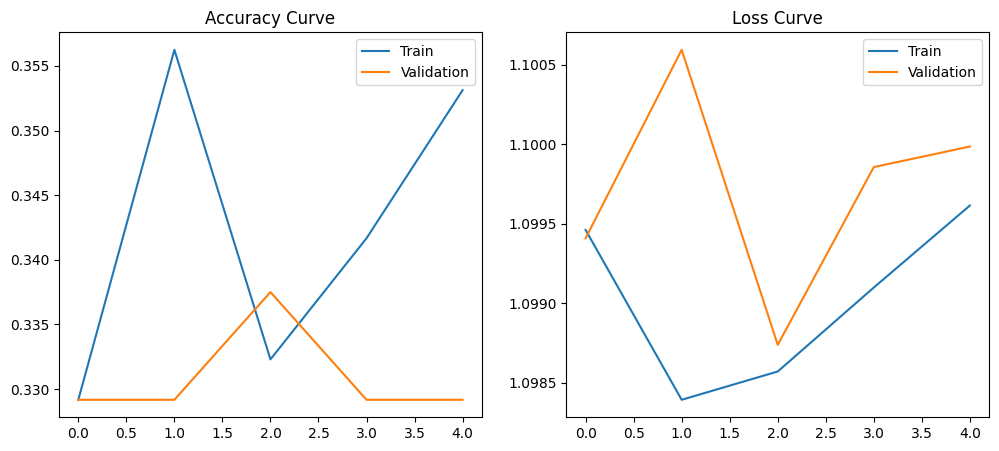

In [66]:
# ==========================================
# SAVE MODEL EVALUATION GRAPH
# ==========================================

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

plt.plot(history.history['accuracy'])

plt.plot(history.history['val_accuracy'])

plt.title("Accuracy Curve")

plt.legend(['Train', 'Validation'])

plt.subplot(1,2,2)

plt.plot(history.history['loss'])

plt.plot(history.history['val_loss'])

plt.title("Loss Curve")

plt.legend(['Train', 'Validation'])

plt.savefig("model_evaluation.png")

plt.show()

In [67]:
# ==========================================
# SAVE SAMPLE PREDICTIONS
# ==========================================

with open("sample_predictions.txt", "w") as file:

    for i in range(5):

        file.write(f"\nMESSAGE:\n")

        file.write(f"{X_test.iloc[i]}\n")

        file.write(f"\nACTUAL: {reverse_mapping[y_test.iloc[i]]}\n")

        file.write(f"PREDICTED: {reverse_mapping[predicted_classes[i]]}\n")

        file.write("\n" + "="*60 + "\n")

print("Sample Predictions Saved")

Sample Predictions Saved


In [68]:
# ==========================================
# DOWNLOAD FILES
# ==========================================

from google.colab import files

files.download("model_evaluation.png")

files.download("sample_predictions.txt")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>